# Duplicate Removal Sensitivity Check

This notebook checks whether the project conclusions are sensitive to the data-cleaning choice of removing exact duplicate rows.

A sensitivity check asks: if we change one important assumption, do the results change in a meaningful way? Here the assumption is whether exact duplicate survey-response rows should be removed. Because the dataset contains mostly discrete/binary survey features, identical rows can occur naturally, so removing about 9% of the original data should be checked rather than assumed harmless.

Two datasets are compared:

1. **Drop exact duplicates**: current main project approach.
2. **Keep exact duplicates**: sensitivity approach.

For both versions, the target is converted from `Diabetes_012` to binary `Diabetes_01`, a stratified train/test split is created, thresholds are selected using train-only 5-fold out-of-fold predictions, and final performance is evaluated on the corresponding held-out test split.

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
raw_path = "../data/raw/diabetes_012_health_indicators_BRFSS2015.csv"
raw_df = pd.read_csv(raw_path)
print(f"Raw data shape: {raw_df.shape}")

Raw data shape: (253680, 22)


## Duplicate Diagnostics

The first question is how large the duplicate issue is. We check exact duplicate rows including the original target and feature-only duplicate groups ignoring the target. Feature-only duplicates with different original labels are especially important because they show that identical feature profiles do not always imply the same diabetes status.

In [2]:
target_column_original = "Diabetes_012"
feature_columns_original = [col for col in raw_df.columns if col != target_column_original]

exact_duplicate_rows = raw_df.duplicated().sum()
exact_duplicate_percent = exact_duplicate_rows / len(raw_df)

exact_group_sizes = raw_df.groupby(list(raw_df.columns), dropna=False).size().rename("Group Size").reset_index()
exact_duplicate_groups = exact_group_sizes.loc[exact_group_sizes["Group Size"] > 1]

feature_group_summary = (
    raw_df
    .groupby(feature_columns_original, dropna=False)
    .agg(
        **{
            "Group Size": (target_column_original, "size"),
            "Target Unique Count": (target_column_original, "nunique"),
            "Target Values": (target_column_original, lambda x: tuple(sorted(x.unique()))),
        }
    )
    .reset_index()
)
feature_duplicate_groups = feature_group_summary.loc[feature_group_summary["Group Size"] > 1]
conflicting_feature_duplicate_groups = feature_duplicate_groups.loc[
    feature_duplicate_groups["Target Unique Count"] > 1
]

summary_df = pd.DataFrame([
    {
        "Check": "Exact duplicate rows including target",
        "Rows or Groups": exact_duplicate_rows,
        "Percent of Raw Rows": exact_duplicate_percent,
        "Largest Group Size": exact_duplicate_groups["Group Size"].max(),
    },
    {
        "Check": "Exact duplicate groups including target",
        "Rows or Groups": len(exact_duplicate_groups),
        "Percent of Raw Rows": np.nan,
        "Largest Group Size": exact_duplicate_groups["Group Size"].max(),
    },
    {
        "Check": "Feature duplicate rows beyond first, ignoring target",
        "Rows or Groups": raw_df.duplicated(subset=feature_columns_original).sum(),
        "Percent of Raw Rows": raw_df.duplicated(subset=feature_columns_original).mean(),
        "Largest Group Size": feature_duplicate_groups["Group Size"].max(),
    },
    {
        "Check": "Feature duplicate groups with conflicting targets",
        "Rows or Groups": len(conflicting_feature_duplicate_groups),
        "Percent of Raw Rows": conflicting_feature_duplicate_groups["Group Size"].sum() / len(raw_df),
        "Largest Group Size": conflicting_feature_duplicate_groups["Group Size"].max(),
    },
])

summary_df.round(4)

,Check,Rows or Groups,Percent of Raw Rows,Largest Group Size
0,Exact duplicate rows including target,23899,0.0942,59
1,Exact duplicate groups including target,11187,NaN,59
2,"Feature duplicate rows beyond first, ignoring ...",25772,0.1016,59
3,Feature duplicate groups with conflicting targets,1834,0.0241,44


In [3]:
display(
    exact_duplicate_groups["Group Size"]
    .value_counts()
    .sort_index(ascending=False)
    .head(15)
    .rename_axis("Exact Duplicate Group Size")
    .reset_index(name="Number of Groups")
)

display(
    conflicting_feature_duplicate_groups["Target Values"]
    .value_counts()
    .rename_axis("Original Target Values in Same Feature Group")
    .reset_index(name="Number of Groups")
)

,Exact Duplicate Group Size,Number of Groups
0,59,1
1,55,1
2,53,1
3,52,2
4,51,1
5,50,1
6,47,1
7,44,1
8,43,3
9,42,3


,Original Target Values in Same Feature Group,Number of Groups
0,"(0.0, 2.0)",1497
1,"(0.0, 1.0)",268
2,"(0.0, 1.0, 2.0)",39
3,"(1.0, 2.0)",30


## Modeling Helper Functions

The same modeling workflow is applied to both duplicate-handling choices. Thresholds are selected from 5-fold out-of-fold predictions on the training split only, then the final model is refit on the full training split and evaluated on the held-out test split.

In [4]:
def prepare_binary_dataset(df, drop_exact_duplicates):
    prepared = df.copy()
    if drop_exact_duplicates:
        prepared = prepared.drop_duplicates().reset_index(drop=True)

    prepared[target_column_original] = (prepared[target_column_original] == 2).astype(int)
    prepared = prepared.rename(columns={target_column_original: "Diabetes_01"})

    float_columns = prepared.select_dtypes(include=["float64"]).columns
    prepared[float_columns] = prepared[float_columns].astype("int64")
    return prepared


def split_dataset(df):
    X = df.drop(columns=["Diabetes_01"])
    y = df["Diabetes_01"]
    return train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=RANDOM_STATE,
    )


def get_best_f2_threshold(y_true, y_score, beta=2):
    precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_true, y_score)
    beta_squared = beta ** 2
    numerator = (1 + beta_squared) * precision_curve[:-1] * recall_curve[:-1]
    denominator = beta_squared * precision_curve[:-1] + recall_curve[:-1]
    fbeta_scores = np.divide(
        numerator,
        denominator,
        out=np.zeros_like(numerator),
        where=denominator != 0,
    )
    return pr_thresholds[fbeta_scores.argmax()]


def get_best_tpr_fpr_threshold(y_true, y_score):
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
    finite_threshold_mask = np.isfinite(roc_thresholds)
    fpr = fpr[finite_threshold_mask]
    tpr = tpr[finite_threshold_mask]
    roc_thresholds = roc_thresholds[finite_threshold_mask]
    return roc_thresholds[(tpr - fpr).argmax()]


def calculate_tpr_fpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    return tpr - fpr


def get_sklearn_scores(estimator, X, score_method):
    if score_method == "predict_proba":
        return estimator.predict_proba(X)[:, 1]
    if score_method == "decision_function":
        return estimator.decision_function(X)
    raise ValueError(f"Unsupported score_method: {score_method}")


def collect_sklearn_oof_scores(model, X, y, score_method):
    fold_predictions = []
    for train_idx, valid_idx in cv_strategy.split(X, y):
        fold_model = clone(model)
        X_fold_train = X.iloc[train_idx]
        X_fold_valid = X.iloc[valid_idx]
        y_fold_train = y.iloc[train_idx]
        y_fold_valid = y.iloc[valid_idx]

        fold_model.fit(X_fold_train, y_fold_train)
        y_valid_score = get_sklearn_scores(fold_model, X_fold_valid, score_method)
        fold_predictions.append(
            pd.DataFrame({"y_true": y_fold_valid.to_numpy(), "y_score": y_valid_score})
        )
    return pd.concat(fold_predictions, ignore_index=True)


def build_threshold_table(y_valid, y_valid_score, default_threshold):
    return pd.DataFrame([
        {"Threshold Strategy": "Default threshold", "Threshold": default_threshold},
        {"Threshold Strategy": "Max F2 threshold", "Threshold": get_best_f2_threshold(y_valid, y_valid_score)},
        {"Threshold Strategy": "Max TPR-FPR threshold", "Threshold": get_best_tpr_fpr_threshold(y_valid, y_valid_score)},
    ])


def score_thresholds(y_true, y_score, threshold_table):
    rows = []
    for _, threshold_row in threshold_table.iterrows():
        threshold = threshold_row["Threshold"]
        y_pred = (y_score >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        rows.append({
            "Threshold Strategy": threshold_row["Threshold Strategy"],
            "Threshold": threshold,
            "Accuracy": accuracy_score(y_true, y_pred),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "F1": f1_score(y_true, y_pred, zero_division=0),
            "F2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
            "AUPRC": average_precision_score(y_true, y_score),
            "AUROC": roc_auc_score(y_true, y_score),
            "Predicted Positive Rate": y_pred.mean(),
            "TPR - FPR": calculate_tpr_fpr(y_true, y_pred),
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
        })
    return pd.DataFrame(rows)

In [5]:
def make_sklearn_model_specs(y_train):
    negative_count = (y_train == 0).sum()
    positive_count = (y_train == 1).sum()
    scale_pos_weight = negative_count / positive_count

    return [
        {
            "Model": "Regular Logistic Regression",
            "Estimator": Pipeline([
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    C=np.inf,
                    solver="lbfgs",
                    class_weight="balanced",
                    max_iter=5000,
                    random_state=RANDOM_STATE,
                )),
            ]),
            "Score Method": "predict_proba",
            "Default Threshold": 0.5,
            "Hyperparameters": "StandardScaler + LogisticRegression(C=np.inf, class_weight=balanced)",
        },
        {
            "Model": "Lasso Logistic Regression (C=1)",
            "Estimator": Pipeline([
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    l1_ratio=1,
                    C=1,
                    solver="saga",
                    class_weight="balanced",
                    max_iter=5000,
                    random_state=RANDOM_STATE,
                )),
            ]),
            "Score Method": "predict_proba",
            "Default Threshold": 0.5,
            "Hyperparameters": "StandardScaler + LogisticRegression(l1_ratio=1, C=1, class_weight=balanced)",
        },
        {
            "Model": "Ridge Logistic Regression (C=1)",
            "Estimator": Pipeline([
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    l1_ratio=0,
                    C=1,
                    solver="lbfgs",
                    class_weight="balanced",
                    max_iter=5000,
                    random_state=RANDOM_STATE,
                )),
            ]),
            "Score Method": "predict_proba",
            "Default Threshold": 0.5,
            "Hyperparameters": "StandardScaler + LogisticRegression(l1_ratio=0, C=1, class_weight=balanced)",
        },
        {
            "Model": "Random Forest",
            "Estimator": RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
            "Score Method": "predict_proba",
            "Default Threshold": 0.5,
            "Hyperparameters": "RandomForestClassifier(n_estimators=200, class_weight=balanced)",
        },
        {
            "Model": "XGBoost",
            "Estimator": XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                scale_pos_weight=scale_pos_weight,
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
            "Score Method": "predict_proba",
            "Default Threshold": 0.5,
            "Hyperparameters": "XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, scale_pos_weight=train ratio)",
        },
        {
            "Model": "Linear SVM",
            "Estimator": Pipeline([
                ("scaler", StandardScaler()),
                ("model", LinearSVC(
                    C=1.0,
                    class_weight="balanced",
                    max_iter=10000,
                    random_state=RANDOM_STATE,
                )),
            ]),
            "Score Method": "decision_function",
            "Default Threshold": 0.0,
            "Hyperparameters": "StandardScaler + LinearSVC(C=1.0, class_weight=balanced)",
        },
    ]


def build_nn_model(input_dim):
    model = keras.Sequential([
        layers.InputLayer(shape=(input_dim,)),
        layers.BatchNormalization(axis=-1),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="rmsprop", loss="binary_crossentropy")
    return model


def get_class_weight(y):
    negative_count = (y == 0).sum()
    positive_count = (y == 1).sum()
    total = len(y)
    return {
        0: total / (2 * negative_count),
        1: total / (2 * positive_count),
    }


def collect_nn_oof_scores(X, y, epochs=100, batch_size=1024):
    fold_predictions = []
    for fold_number, (train_idx, valid_idx) in enumerate(cv_strategy.split(X, y), start=1):
        tf.keras.utils.set_random_seed(RANDOM_STATE + fold_number)
        model = build_nn_model(X.shape[1])
        X_fold_train = X.iloc[train_idx]
        X_fold_valid = X.iloc[valid_idx]
        y_fold_train = y.iloc[train_idx]
        y_fold_valid = y.iloc[valid_idx]

        early_stop = keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )
        model.fit(
            X_fold_train,
            y_fold_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.1,
            class_weight=get_class_weight(y_fold_train),
            callbacks=[early_stop],
            verbose=0,
        )
        y_valid_score = model.predict(X_fold_valid, verbose=0).ravel()
        fold_predictions.append(
            pd.DataFrame({"y_true": y_fold_valid.to_numpy(), "y_score": y_valid_score})
        )
    return pd.concat(fold_predictions, ignore_index=True)


def fit_nn_and_score(X_train, y_train, X_test, epochs=100, batch_size=1024):
    tf.keras.utils.set_random_seed(RANDOM_STATE)
    model = build_nn_model(X_train.shape[1])
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    )
    model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        class_weight=get_class_weight(y_train),
        callbacks=[early_stop],
        verbose=0,
    )
    return model.predict(X_test, verbose=0).ravel()

## Run Sensitivity Models

This cell may take a few minutes because each data version runs the full set of models with 5-fold threshold selection.

In [6]:
scenario_specs = [
    {"Scenario": "Drop exact duplicates", "Drop Exact Duplicates": True},
    {"Scenario": "Keep exact duplicates", "Drop Exact Duplicates": False},
]

all_score_frames = []
all_dataset_rows = []

for scenario_spec in scenario_specs:
    scenario_name = scenario_spec["Scenario"]
    print(f"Running scenario: {scenario_name}")

    scenario_df = prepare_binary_dataset(
        raw_df,
        drop_exact_duplicates=scenario_spec["Drop Exact Duplicates"],
    )
    X_train, X_test, y_train, y_test = split_dataset(scenario_df)

    all_dataset_rows.append({
        "Scenario": scenario_name,
        "Rows": len(scenario_df),
        "Train Rows": len(X_train),
        "Test Rows": len(X_test),
        "Positive Rate": y_train.mean(),
        "Test Positive Rate": y_test.mean(),
    })

    dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
    dummy.fit(X_train, y_train)
    dummy_score = np.zeros(len(y_test))
    dummy_threshold_table = pd.DataFrame([
        {"Threshold Strategy": "Default baseline", "Threshold": 0.5}
    ])
    dummy_scores = score_thresholds(y_test, dummy_score, dummy_threshold_table)
    dummy_scores.insert(0, "Model", "Dummy Classifier")
    dummy_scores.insert(0, "Scenario", scenario_name)
    dummy_scores["Hyperparameters"] = "DummyClassifier(strategy=most_frequent)"
    all_score_frames.append(dummy_scores)

    for spec in make_sklearn_model_specs(y_train):
        print(f"  {spec['Model']}")
        oof_scores = collect_sklearn_oof_scores(
            spec["Estimator"],
            X_train,
            y_train,
            spec["Score Method"],
        )
        threshold_table = build_threshold_table(
            oof_scores["y_true"],
            oof_scores["y_score"],
            default_threshold=spec["Default Threshold"],
        )

        final_model = clone(spec["Estimator"])
        final_model.fit(X_train, y_train)
        y_test_score = get_sklearn_scores(final_model, X_test, spec["Score Method"])

        model_scores = score_thresholds(y_test, y_test_score, threshold_table)
        model_scores.insert(0, "Model", spec["Model"])
        model_scores.insert(0, "Scenario", scenario_name)
        model_scores["Hyperparameters"] = spec["Hyperparameters"]
        all_score_frames.append(model_scores)

    print("  MLP Neural Network")
    nn_oof_scores = collect_nn_oof_scores(X_train, y_train)
    nn_threshold_table = build_threshold_table(
        nn_oof_scores["y_true"],
        nn_oof_scores["y_score"],
        default_threshold=0.5,
    )
    nn_test_score = fit_nn_and_score(X_train, y_train, X_test)
    nn_scores = score_thresholds(y_test, nn_test_score, nn_threshold_table)
    nn_scores.insert(0, "Model", "MLP Neural Network")
    nn_scores.insert(0, "Scenario", scenario_name)
    nn_scores["Hyperparameters"] = "BatchNorm + Dense(64, relu) + Dense(32, relu) + Dense(1, sigmoid)"
    all_score_frames.append(nn_scores)

sensitivity_dataset_df = pd.DataFrame(all_dataset_rows)
sensitivity_scores_df = pd.concat(all_score_frames, ignore_index=True)

print("Sensitivity check complete.")

Running scenario: Drop exact duplicates


  Regular Logistic Regression


  Lasso Logistic Regression (C=1)


  Ridge Logistic Regression (C=1)


  Random Forest


...

  Random Forest


  XGBoost


  Linear SVM


  MLP Neural Network


Sensitivity check complete.


## Dataset Size Comparison

In [7]:
sensitivity_dataset_df.round(6)

,Scenario,Rows,Train Rows,Test Rows,Positive Rate,Test Positive Rate
0,Drop exact duplicates,229781,183824,45957,0.152738,0.152751
1,Keep exact duplicates,253680,202944,50736,0.139334,0.139329


## Full Sensitivity Score Table

In [8]:
score_columns = [
    "Scenario",
    "Model",
    "Hyperparameters",
    "Threshold Strategy",
    "Threshold",
    "Accuracy",
    "Recall",
    "Precision",
    "F1",
    "F2",
    "AUPRC",
    "AUROC",
    "Predicted Positive Rate",
    "TPR - FPR",
    "TN",
    "FP",
    "FN",
    "TP",
]

sensitivity_scores_df = sensitivity_scores_df[score_columns]
sensitivity_scores_df.round(6)

,Scenario,Model,Hyperparameters,Threshold Strategy,Threshold,Accuracy,Recall,Precision,F1,F2,AUPRC,AUROC,Predicted Positive Rate,TPR - FPR,TN,FP,FN,TP
0,Drop exact duplicates,Dummy Classifier,DummyClassifier(strategy=most_frequent),Default baseline,0.500000,0.847249,0.000000,0.000000,0.000000,0.000000,0.152751,0.500000,0.000000,0.000000,38937,0,7020,0
1,Drop exact duplicates,Regular Logistic Regression,"StandardScaler + LogisticRegression(C=np.inf, ...",Default threshold,0.500000,0.718868,0.758832,0.321795,0.451939,0.596742,0.413403,0.811550,0.360206,0.470494,27710,11227,1693,5327
2,Drop exact duplicates,Regular Logistic Regression,"StandardScaler + LogisticRegression(C=np.inf, ...",Max F2 threshold,0.402278,0.649629,0.855983,0.284787,0.427383,0.610919,0.413403,0.811550,0.459125,0.468408,23846,15091,1011,6009
3,Drop exact duplicates,Regular Logistic Regression,"StandardScaler + LogisticRegression(C=np.inf, ...",Max TPR-FPR threshold,0.458578,0.690863,0.802849,0.305325,0.442404,0.605514,0.413403,0.811550,0.401658,0.473522,26114,12823,1384,5636
4,Drop exact duplicates,Lasso Logistic Regression (C=1),StandardScaler + LogisticRegression(l1_ratio=1...,Default threshold,0.500000,0.718868,0.758689,0.321774,0.451892,0.596657,0.413400,0.811547,0.360163,0.470378,27711,11226,1694,5326
5,Drop exact duplicates,Lasso Logistic Regression (C=1),StandardScaler + LogisticRegression(l1_ratio=1...,Max F2 threshold,0.402686,0.649977,0.855840,0.284982,0.427585,0.611041,0.413400,0.811547,0.458733,0.468702,23863,15074,1012,6008
6,Drop exact duplicates,Lasso Logistic Regression (C=1),StandardScaler + LogisticRegression(l1_ratio=1...,Max TPR-FPR threshold,0.461313,0.693191,0.801425,0.306895,0.443831,0.606093,0.413400,0.811547,0.398895,0.475102,26231,12706,1394,5626
7,Drop exact duplicates,Ridge Logistic Regression (C=1),StandardScaler + LogisticRegression(l1_ratio=0...,Default threshold,0.500000,0.718868,0.758832,0.321795,0.451939,0.596742,0.413403,0.811550,0.360206,0.470494,27710,11227,1693,5327
8,Drop exact duplicates,Ridge Logistic Regression (C=1),StandardScaler + LogisticRegression(l1_ratio=0...,Max F2 threshold,0.402283,0.649651,0.855983,0.284800,0.427398,0.610931,0.413403,0.811550,0.459103,0.468434,23847,15090,1011,6009
9,Drop exact duplicates,Ridge Logistic Regression (C=1),StandardScaler + LogisticRegression(l1_ratio=0...,Max TPR-FPR threshold,0.458536,0.690841,0.802849,0.305309,0.442386,0.605501,0.413403,0.811550,0.401680,0.473496,26113,12824,1384,5636


## Sensitivity Difference Table

The table below subtracts the current main approach from the sensitivity approach:

`Keep exact duplicates - Drop exact duplicates`

Large deltas mean the duplicate-removal decision materially changes model behavior. Small deltas mean the conclusions are less sensitive to the duplicate-removal assumption.

In [9]:
metric_columns = [
    "Accuracy",
    "Recall",
    "Precision",
    "F1",
    "F2",
    "AUPRC",
    "AUROC",
    "Predicted Positive Rate",
    "TPR - FPR",
]

comparison_index = ["Model", "Threshold Strategy"]
wide_scores = sensitivity_scores_df.pivot_table(
    index=comparison_index,
    columns="Scenario",
    values=metric_columns,
)

delta_frames = []
for metric in metric_columns:
    delta = (
        wide_scores[(metric, "Keep exact duplicates")] -
        wide_scores[(metric, "Drop exact duplicates")]
    ).rename(f"Delta {metric}")
    delta_frames.append(delta)

sensitivity_delta_df = pd.concat(delta_frames, axis=1).reset_index()
sensitivity_delta_ranked_df = (
    sensitivity_delta_df
    .assign(Abs_Delta_Recall=lambda df: df["Delta Recall"].abs())
    .sort_values("Abs_Delta_Recall", ascending=False)
    .drop(columns="Abs_Delta_Recall")
    .reset_index(drop=True)
)
sensitivity_delta_ranked_df.insert(0, "Rank", np.arange(1, len(sensitivity_delta_ranked_df) + 1))
sensitivity_delta_ranked_df.round(6)

,Rank,Model,Threshold Strategy,Delta Accuracy,Delta Recall,Delta Precision,Delta F1,Delta F2,Delta AUPRC,Delta AUROC,Delta Predicted Positive Rate,Delta TPR - FPR
0,1,MLP Neural Network,Max F2 threshold,0.065342,-0.063839,0.015523,0.008454,-0.013651,-0.033664,0.002635,-0.092871,0.026427
1,2,MLP Neural Network,Default threshold,0.040119,-0.055964,0.003791,-0.005318,-0.023758,-0.033664,0.002635,-0.063993,0.001754
2,3,MLP Neural Network,Max TPR-FPR threshold,0.041803,-0.055635,0.003956,-0.004564,-0.022637,-0.033664,0.002635,-0.065952,0.004420
3,4,XGBoost,Max TPR-FPR threshold,-0.003114,0.021587,-0.021370,-0.018687,-0.006238,-0.020656,0.006448,0.001511,0.015760
4,5,Linear SVM,Max F2 threshold,0.032693,-0.021078,-0.001854,-0.004730,-0.010323,-0.020581,0.008272,-0.048153,0.024167
5,6,Ridge Logistic Regression (C=1),Max F2 threshold,0.026102,-0.012865,-0.005014,-0.007251,-0.009858,-0.020818,0.008081,-0.039243,0.023343
6,7,Lasso Logistic Regression (C=1),Max F2 threshold,0.025795,-0.012723,-0.005183,-0.007423,-0.009956,-0.020804,0.008082,-0.038893,0.023098
7,8,Regular Logistic Regression,Max F2 threshold,0.022202,-0.009470,-0.007094,-0.009184,-0.010417,-0.020819,0.008081,-0.034397,0.021657
8,9,Random Forest,Max TPR-FPR threshold,0.015531,0.006429,-0.008623,-0.008151,-0.003983,0.000948,0.013192,-0.020891,0.024976
9,10,Regular Logistic Regression,Max TPR-FPR threshold,0.013627,0.005469,-0.010059,-0.009869,-0.005656,-0.020819,0.008081,-0.020233,0.022478


## Visual Comparison

These plots focus on the screening-oriented max-F2 threshold because that threshold often gives high recall and is close to the project goal of identifying more diabetes cases.

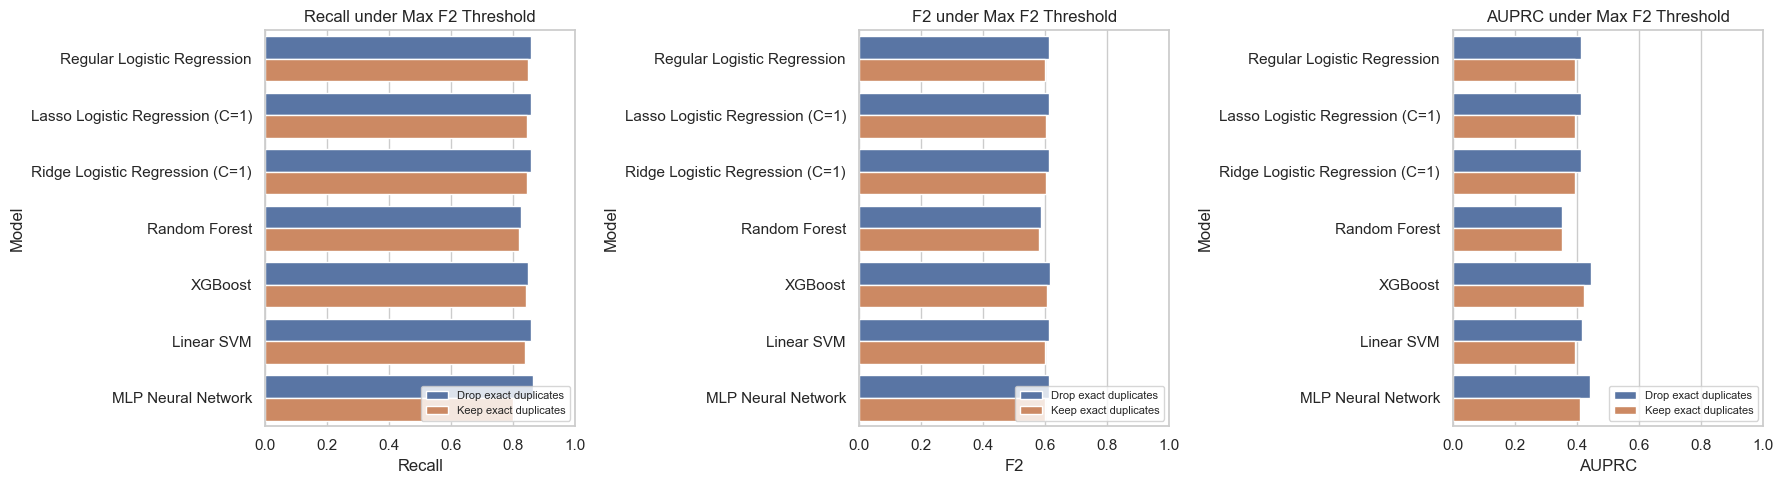

In [10]:
plot_df = sensitivity_scores_df.loc[
    sensitivity_scores_df["Threshold Strategy"] == "Max F2 threshold"
].copy()
plot_df = plot_df.loc[plot_df["Model"] != "Dummy Classifier"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ["Recall", "F2", "AUPRC"]):
    sns.barplot(
        data=plot_df,
        x=metric,
        y="Model",
        hue="Scenario",
        ax=ax,
    )
    ax.set_title(f"{metric} under Max F2 Threshold")
    ax.set_xlim(0, max(1.0, plot_df[metric].max() * 1.05))
    ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## Interpretation Notes for Final Report

Use this section after running the notebook:

- If the main model ranking is similar across the two scenarios, we can say the duplicate-removal decision does not materially change the conclusions.
- If recall, F2, AUPRC, or AUROC change substantially, the final report should state that model performance is sensitive to the duplicate-removal assumption.
- Feature-only duplicate groups with different target labels are not automatically data errors. In this BRFSS survey dataset, many respondents can share the same discrete feature profile while having different diabetes outcomes.
- The current project can keep the deduplicated data as the primary analysis, but the sensitivity results should be reported because removing 9% of rows is a meaningful cleaning decision.